# Run differential accessibility in CD4 naive cells in p

# load libraries

In [1]:
# load libraries
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("ArchR")
quiet_library("data.table")
quiet_library("jsonlite")
quiet_library("parallel")
# Load MOCHA and accompanying libraries
quiet_library("MOCHA")
quiet_library("GenomicRanges")
quiet_library("plyranges")


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
# define work directories
proj_path <- "/home/workspace/data/preRA_teaseq/EXP-00243"
data_path <- "/home/workspace/data/preRA_teaseq/EXP-00243"
setwd(proj_path)
# define a project name

In [4]:
# set ArchR parameters
addArchRThreads(threads = 3)
addArchRGenome("hg38")
set.seed(1221)
options(repr.plot.width = 20, repr.plot.height = 15)

Input threads is equal to or greater than ncores minus 1 (3)
Setting cores to ncores minus 2. Set force = TRUE to set above this number!

Setting default number of Parallel threads to 2.

Setting default genome to Hg38.



In [5]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
status_colors <- c("#5AAA46", "#F59F00", "#840032")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [6]:
# define work directories
proj_path <- "/home/workspace/data/preRA_teaseq/EXP-00243/cd4tna_cells"
setwd(proj_path)
# define a project name
proj_name <- "preRA_tea_seq_cd4tna"
fig_path <- as.character("/home/workspace/data/preRA_teaseq/EXP-00243/cd4tna_cells/Plots")
output_path <- "/home/workspace/data/preRA_teaseq/output_results/atac"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(fig_path, recursive = TRUE))

In [7]:
# Define your annotation package for TxDb object(s)
# and genome-wide annotation.
# Here our samples are human using hg38 as a reference.
# For more info: <https://bioconductor.org/packages/3.15/data/annotation/>

library(TxDb.Hsapiens.UCSC.hg38.refGene)
library(org.Hs.eg.db)
TxDb <- TxDb.Hsapiens.UCSC.hg38.refGene
Org <- org.Hs.eg.db

Loading required package: GenomicFeatures

Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:plyranges’:

    select


The following object is masked from ‘package:dplyr’:

    select






# load cd4 naive t cells atac data

In [8]:
# load ATAC
# load the ArchR project for CD4 t cells
cd4na_atac <- loadArchRProject(path = "/home/workspace/data/preRA_teaseq/EXP-00243/cd4tna_cells")
cd4na_atac

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

class: ArchRProject 
outputDirectory: /home/workspace/data/preRA_teaseq/EXP-00243/cd4tna_cells 
samples(12): EXP-00243-P1_PB00067-03 EXP-00243-P1_PB00073-03 ...
  EXP-00243-P1_PB00501-03 EXP-00243-P1_PB00212-03
sampleColData names(1): ArrowFiles
cellColData names(49): barcodes Sample ... MochaPeak_clusters_1
  Clusters_0.5
numberOfCells(1): 22960
medianTSS(1): 26.432
medianFrags(1): 5148

## add atac inforation back to the naive t cells seurat object

In [ ]:
# load the seurat object
ra_tea_cd4na <- readRDS(file.path(data_path, "PreRA_teaseq_seurat_cd4naive_t_cells_06112023.rds"))

In [ ]:
ra_tea_cd4na

In [ ]:
# ra_tea_cd4na@meta.data %>% colnames()
kit_id <- str_split(ra_tea_cd4na@meta.data %>% distinct(pbmc_sample_id) %>% pull(pbmc_sample_id),
  pattern = "-", simplify = TRUE
)[, 1] %>% str_replace("PB", "KT")
kit_id %>% paste(collapse = ", ")

In [ ]:
ra_tea_cd4na@meta.data %>%
  distinct(subject_id) %>%
  pull(subject_id)

In [ ]:
# check all the atac barcodes matched
ra_tea_cd4na@meta.data %>% colnames()
all(ra_tea_cd4na@meta.data$atac_cell_id %in% cd4na_atac$cellNames)
all(cd4na_atac$cellNames %in% ra_tea_cd4na@meta.data$atac_cell_id)

In [ ]:
# extracts the RNA counts from a Seurat object and adds them to an ArchR Project
cd4na_atac <- addSeuratRNA(
  SeuratObject = ra_tea_cd4na, ArchRProject = cd4na_atac,
  "atac_cell_id", assay = "SCT"
)

In [ ]:
getAvailableMatrices(cd4na_atac)

In [ ]:
# cd4na_atac
# ra_tea_cd4na

In [ ]:
metacols <- c(
  "barcodes", "predicted.celltype_l2",
  "wsnn_res.0.3", "age", "total_counts"
)
metacols %in% colnames(ra_tea_cd4na@meta.data)
metacols %in% colnames(getCellColData(cd4na_atac))

In [ ]:
# add some metadate from seurat to archR
getCellColData(cd4na_atac) %>% colnames()
cd4na_atac <- MetaSotoArchr(
  archr = cd4na_atac, so = ra_tea_cd4na,
  so.cols = c(
    "barcodes",
    "predicted.celltype_l2",
    "wsnn_res.0.3", "age", "total_counts"
  ),
  id.col = "barcodes"
)

In [ ]:
getCellColData(cd4na_atac) %>% colnames()

In [15]:
cd4na_atac <- addClusters(
  input = cd4na_atac,
  reducedDims = "IterativeLSI",
  method = "Seurat",
  name = "Clusters_0.5",
  resolution = 0.5,
  force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addClusters-73fdc8c260-Date-2024-07-12_Time-18-37-27.780562.log
If there is an issue, please report to github with logFile!

2024-07-12 18:37:43.040941 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.25 mins elapsed.

Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 22960
Number of edges: 511264

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8184
Number of communities: 6
Elapsed time: 4 seconds


2024-07-12 18:38:14.320582 : Testing Outlier Clusters, 0.771 mins elapsed.

2024-07-12 18:38:14.326116 : Assigning Cluster Names to 6 Clusters, 0.771 mins elapsed.

2024-07-12 18:38:14.469781 : Finished addClusters, 0.774 mins elapsed.



In [16]:
saveArchRProject(ArchRProj = cd4na_atac)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /home/jupyter/data/preRA_teaseq/EXP-00243/cd4tna_cells 
samples(12): EXP-00243-P1_PB00067-03 EXP-00243-P1_PB00073-03 ...
  EXP-00243-P1_PB00501-03 EXP-00243-P1_PB00212-03
sampleColData names(1): ArrowFiles
cellColData names(49): barcodes Sample ... MochaPeak_clusters_1
  Clusters_0.5
numberOfCells(1): 22960
medianTSS(1): 26.432
medianFrags(1): 5148

In [ ]:
# add archr clusters into seurat
atac_clusters_0.5 <- getCellColData(cd4na_atac) %>%
  as_tibble() %>%
  dplyr::select(Clusters_0.5, barcodes) %>%
  dplyr::rename("archr_clusters_0.5" = "Clusters_0.5")
cell_id <- ra_tea_cd4na@meta.data %>% rownames()
ra_tea_cd4na@meta.data <- ra_tea_cd4na@meta.data %>% left_join(atac_clusters_0.5, by = "barcodes")
rownames(ra_tea_cd4na@meta.data) <- cell_id

In [ ]:
# load the seurat object
ra_tea_cd4na %>% saveRDS(file.path(data_path, "PreRA_teaseq_seurat_cd4naive_t_cells_06112023.rds"))

# call peaks using MOCHA and run differential

In [10]:
getCellColData(cd4na_atac) %>%
  as_tibble() %>%
  group_by(subject_id) %>%
  tally()

subject_id,n
<chr>,<int>
BR1019,2247
BR1031,1676
BR2018,1869
BR2029,1342
BR2034,1514
CU1002,1888
CU1004,1006
CU1005,2485
CU1009,1957


In [16]:
cd4na_atac$cd4t_annotation <- "CD4 Naive"

In [ ]:
getCellColData(cd4na_atac) %>% colnames()

In [ ]:
cd4na_atac$clean_l2_cell_types <- "cd4_naive"

In [ ]:
# # call peaks in total CD4 naive cells
cellPopulations <- cd4na_atac$clean_l2_cell_types %>% unique()
cellPopLabel <- "clean_l2_cell_types"
numCores <- 55
groupColumn <- "cohort"
join <- "union"

In [ ]:
cd4na_atac$clean_l2_cell_types %>% unique()

In [ ]:
# getting studySignal from the archr project that has all the cells

# load archR data
ra_atac <- loadArchRProject(path = "/home/workspace/data/preRA_teaseq/EXP-00243/atac_arrows")
studySignal <- median(ra_atac@cellColData$nFrags)
studySignal

In [ ]:
getCellColData(cd4na_atac) %>%
  colnames() %>%
  sort()

## call peaks in Naive T cells

In [ ]:
####################################################
# 2. Call open tiles (main peak calling step)
#    Done once for all specified cell populations
####################################################
cd4na_tileResults <- MOCHA::callOpenTiles(
  cd4na_atac,
  studySignal = studySignal,
  cellPopLabel = "clean_l2_cell_types",
  cellPopulations = "cd4_naive",
  numCores = numCores,
  outDir = "/home/workspace/data/preRA_teaseq/EXP-00243/cd4tna_cells/MOCHA",
  TxDb = "TxDb.Hsapiens.UCSC.hg38.refGene",
  OrgDb = "org.Hs.eg.db"
)

In [ ]:
# load the tile matrix from mocha
cd4na_tileResults %>% saveRDS(file.path(
  output_path,
  paste0(proj_name, "_MOCHA_atac_total_cd4na_tiles_matrix.rds")
))

In [15]:
# Parameters for downstream analysis
cellPopulation <- "cd4_naive"
threshold <- 0.2
groupColumn <- "cohort"
join <- "union"

In [ ]:
####################################################
# 3. Get reproducible sample-peak matrix
#    Done for each cell population individually
####################################################


SampleTileMatrices <- MOCHA::getSampleTileMatrix(
  cd4na_tileResults,
  cellPopulations = cellPopulations,
  groupColumn = groupColumn,
  threshold = threshold
)

In [ ]:
####################################################
# 4. Add gene annotations to our SampleTileMatrices,
#    labelling tiles as either a promoter, exonic,
#    intronic, or distal region. Gene names are
#    given for all but distal. This info will aid
#    further downstream analyses but is not required
#    for differential accessibility.
#    This function can also take any GRanges object
#    and add annotations to its metadata.
####################################################
SampleTileMatricesAnnotated <- MOCHA::annotateTiles(
  SampleTileMatrices
)

In [ ]:
# Load a curated motif set from library(chromVARmotifs)
# included with ArchR installation
library(chromVARmotifs)
data("human_pwms_v2")
SampleTileMatricesAnnotated <- MOCHA::addMotifSet(
  motifPWMs = human_pwms_v2,
  SampleTileMatricesAnnotated,
  # pwms = human_pwms_v2,
  w = 7 # width parameter for motifmatchr::matchMotifs()
)

In [ ]:
SampleTileMatricesAnnotated %>% saveRDS(file.path(
  output_path,
  paste0(proj_name, "_MOCHA_total_cd4na_SampleTileMatrices.rds")
))

In [11]:
# load the sample tile matrix
SampleTileMatricesAnnotated <- readRDS("/home/workspace/data/preRA_teaseq/output_results/atac/preRA_tea_seq_cd4tna_MOCHA_total_cd4na_SampleTileMatrices.rds")

In [12]:
SampleTileMatricesAnnotated

class: RangedSummarizedExperiment 
dim: 517979 12 
metadata(7): summarizedData Genome ... History Motifs
assays(1): cd4_naive
rownames(517979): chr1:1000000-1000499 chr1:100006000-100006499 ...
  chrX:9997500-9997999 chrY:26409000-26409499
rowData names(3): cd4_naive tileType Gene
colnames(12): EXP-00243-P1_PB00060-02 EXP-00243-P1_PB00065-05 ...
  EXP-00243-P1_PB00561-03 EXP-00243-P1_PB00569-04
colData names(11): Sample pool_id ... clean_l2_cell_types
  cd4t_annotation

## run dap analysis in cd4 naive

In [13]:
# check normalized frag counts matrix
cd4na_Matrix <- MOCHA::getCellPopMatrix(SampleTileMatricesAnnotated, "cd4_naive")
cd4na_Matrix[1:5, 1:5]

,EXP-00243-P1_PB00060-02,EXP-00243-P1_PB00065-05,EXP-00243-P1_PB00067-03,EXP-00243-P1_PB00073-03,EXP-00243-P1_PB00096-05
chr1:1000000-1000499,7675.8549,5699.3950,6939.85561,6280.06929,5780.42635
chr1:100006000-100006499,0.0000,0.0000,0.00000,0.00000,0.00000
chr1:100023500-100023999,103.0316,180.9332,95.06652,71.77222,0.00000
chr1:100024500-100024999,103.0316,0.0000,95.06652,215.31666,69.64369
chr1:100028000-100028499,103.0316,0.0000,0.00000,71.77222,208.93107


In [17]:
# check the signal distribution in all the cell types
# extract all the tile matrix for all population
tile_dt <- lapply(cellPopulation, function(x) {
  tile_mx <- getCellPopMatrix(SampleTileMatricesAnnotated, x) %>%
    as.data.table(keep.rownames = "tiles") %>%
    pivot_longer(
      cols = -tiles, names_to = "Sample",
      values_to = "Normalized_counts"
    ) %>%
    mutate(cell_type = x) %>%
    as.data.table()
  meta_data <- colData(SampleTileMatricesAnnotated) %>%
    as_tibble() %>%
    dplyr::select(subject_id, cohort, Sex, Sample)
  tile_mx <- tile_mx %>%
    left_join(meta_data, by = "Sample") %>%
    as.data.table()
}) %>% rbindlist()

In [18]:
tile_dt %>% head()

tiles,Sample,Normalized_counts,cell_type,subject_id,cohort,Sex
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
chr1:1000000-1000499,EXP-00243-P1_PB00060-02,7675.855,cd4_naive,CU1005,pre-RA,Female
chr1:1000000-1000499,EXP-00243-P1_PB00065-05,5699.395,cd4_naive,CU1013,pre-RA,Female
chr1:1000000-1000499,EXP-00243-P1_PB00067-03,6939.856,cd4_naive,CU1019,pre-RA,Female
chr1:1000000-1000499,EXP-00243-P1_PB00073-03,6280.069,cd4_naive,CU1022,pre-RA,Female
chr1:1000000-1000499,EXP-00243-P1_PB00096-05,5780.426,cd4_naive,CU1002,pre-RA,Female
chr1:1000000-1000499,EXP-00243-P1_PB00212-03,5507.805,cd4_naive,CU1004,pre-RA,Female


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


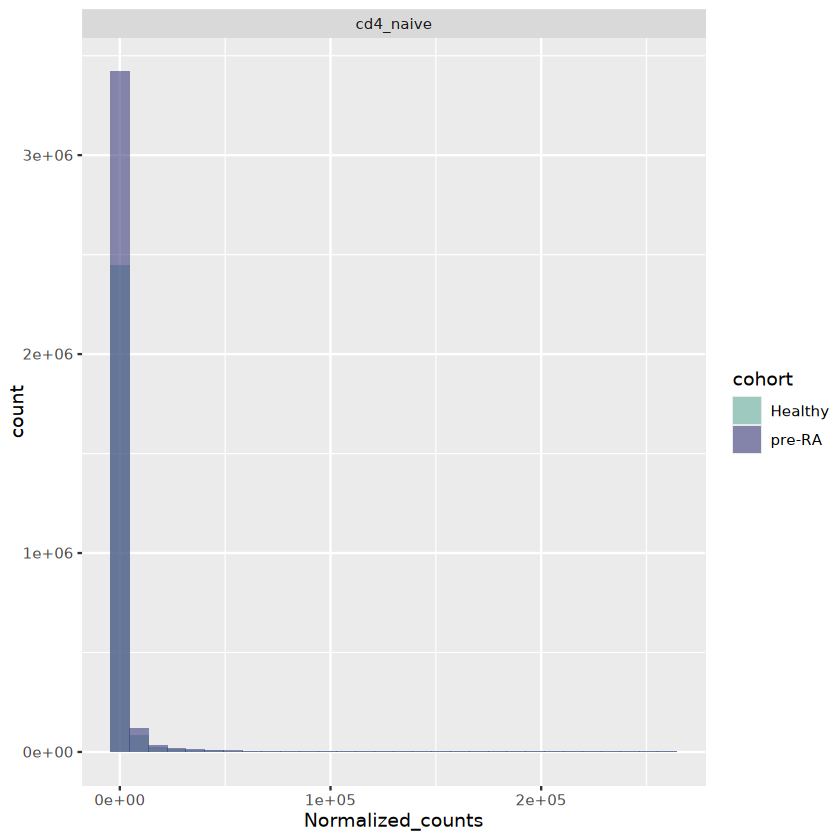

In [19]:
p1 <- tile_dt %>% ggplot() +
  geom_histogram(aes(x = Normalized_counts, fill = cohort),
    position = "identity", alpha = 0.6
  ) +
  facet_wrap(vars(cell_type)) +
  scale_fill_manual(values = c("#69b3a2", "#404080"))
p1
ggsave(file.path(fig_path, paste0(
  proj_name,
  "_mocha_peaks_cell_type_histogram.pdf"
)), width = 12, height = 8)

### run differential accessibility in CD4 naive

In [55]:
#  Get differential accessibility
threshold <- 0.2
groupColumn <- "cohort"
join <- "union"
numCores <- 58

cd4na_diff <- MOCHA::getDifferentialAccessibleTiles(
  SampleTileObj = SampleTileMatricesAnnotated,
  cellPopulation = "cd4_naive",
  groupColumn = groupColumn,
  foreground = "pre-RA",
  background = "Healthy",
  fdrToDisplay = 0.2,
  signalThreshold = 14,
  # minZeroDiff = 0,
  numCores = numCores
)

In [57]:
cd4na_diff <- annotateTiles(cd4na_diff, TxDb = TxDb, Org = Org)

'select()' returned 1:1 mapping between keys and columns



In [58]:
cd4na_diff %>%
  as_tibble() %>%
  filter(FDR < 0.1 & P_value < 0.05) %>%
  group_by(tileType) %>%
  tally()

tileType,n
<chr>,<int>
Distal,829
Promoter,2200


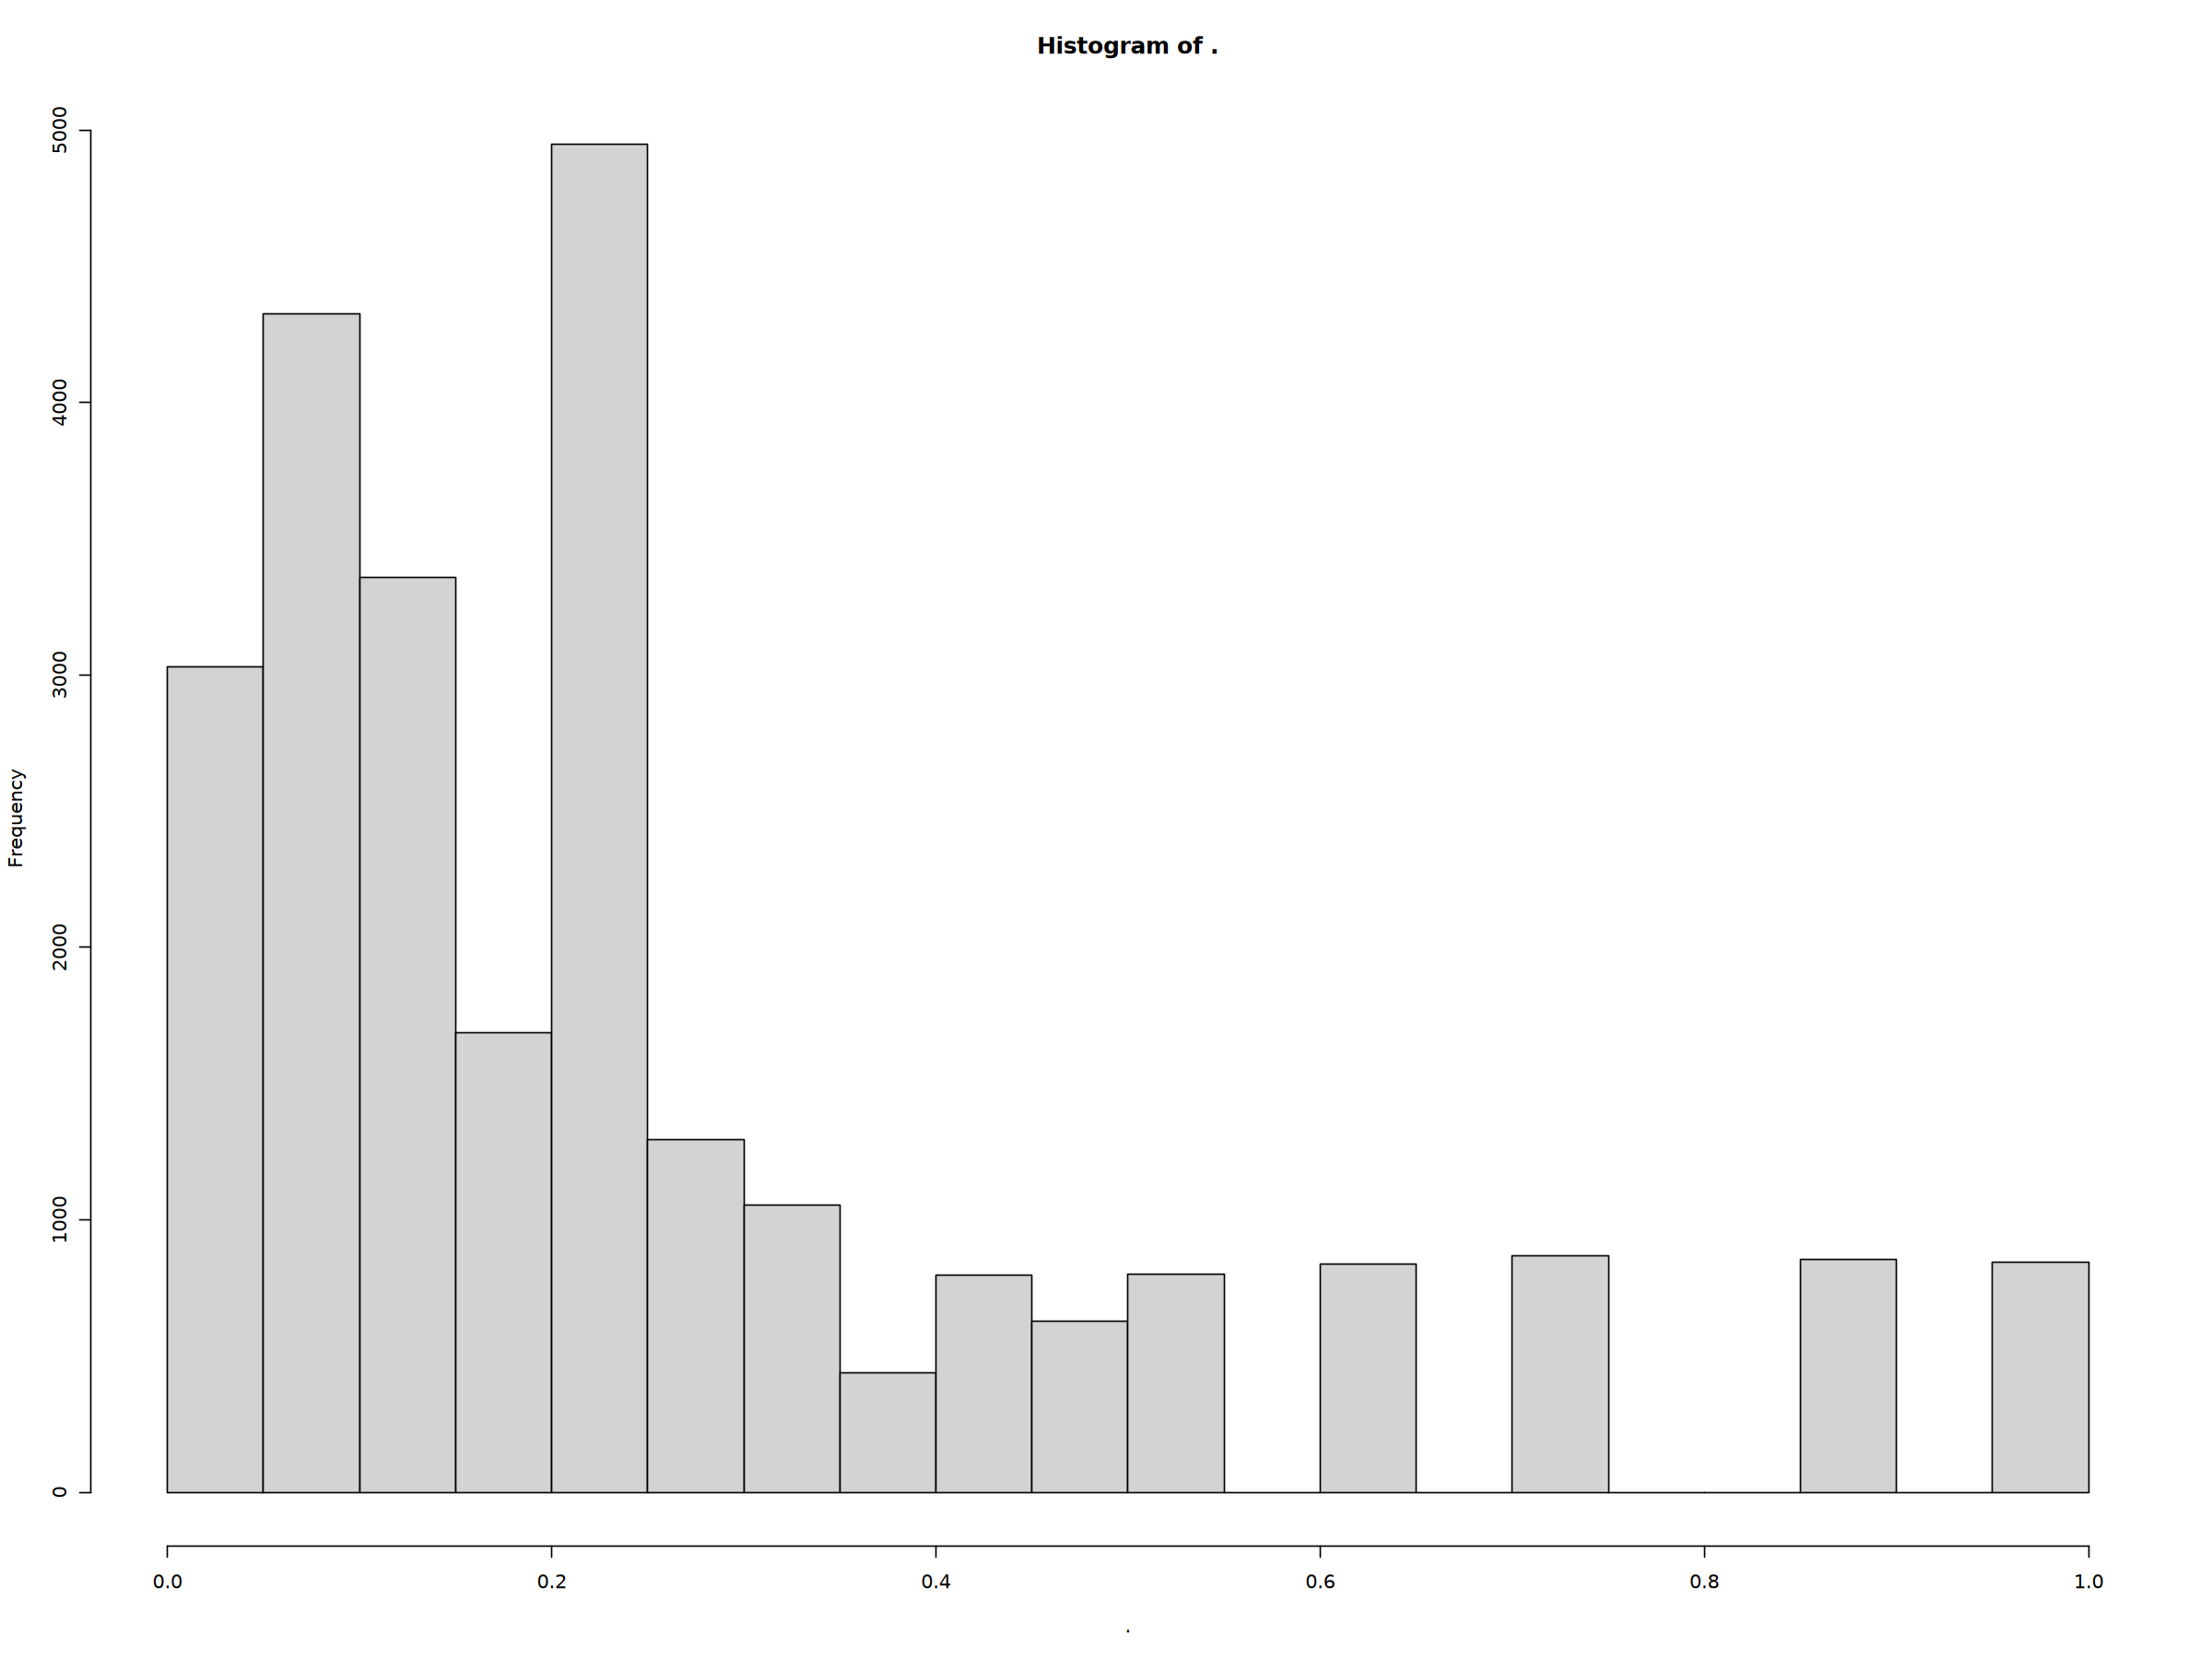

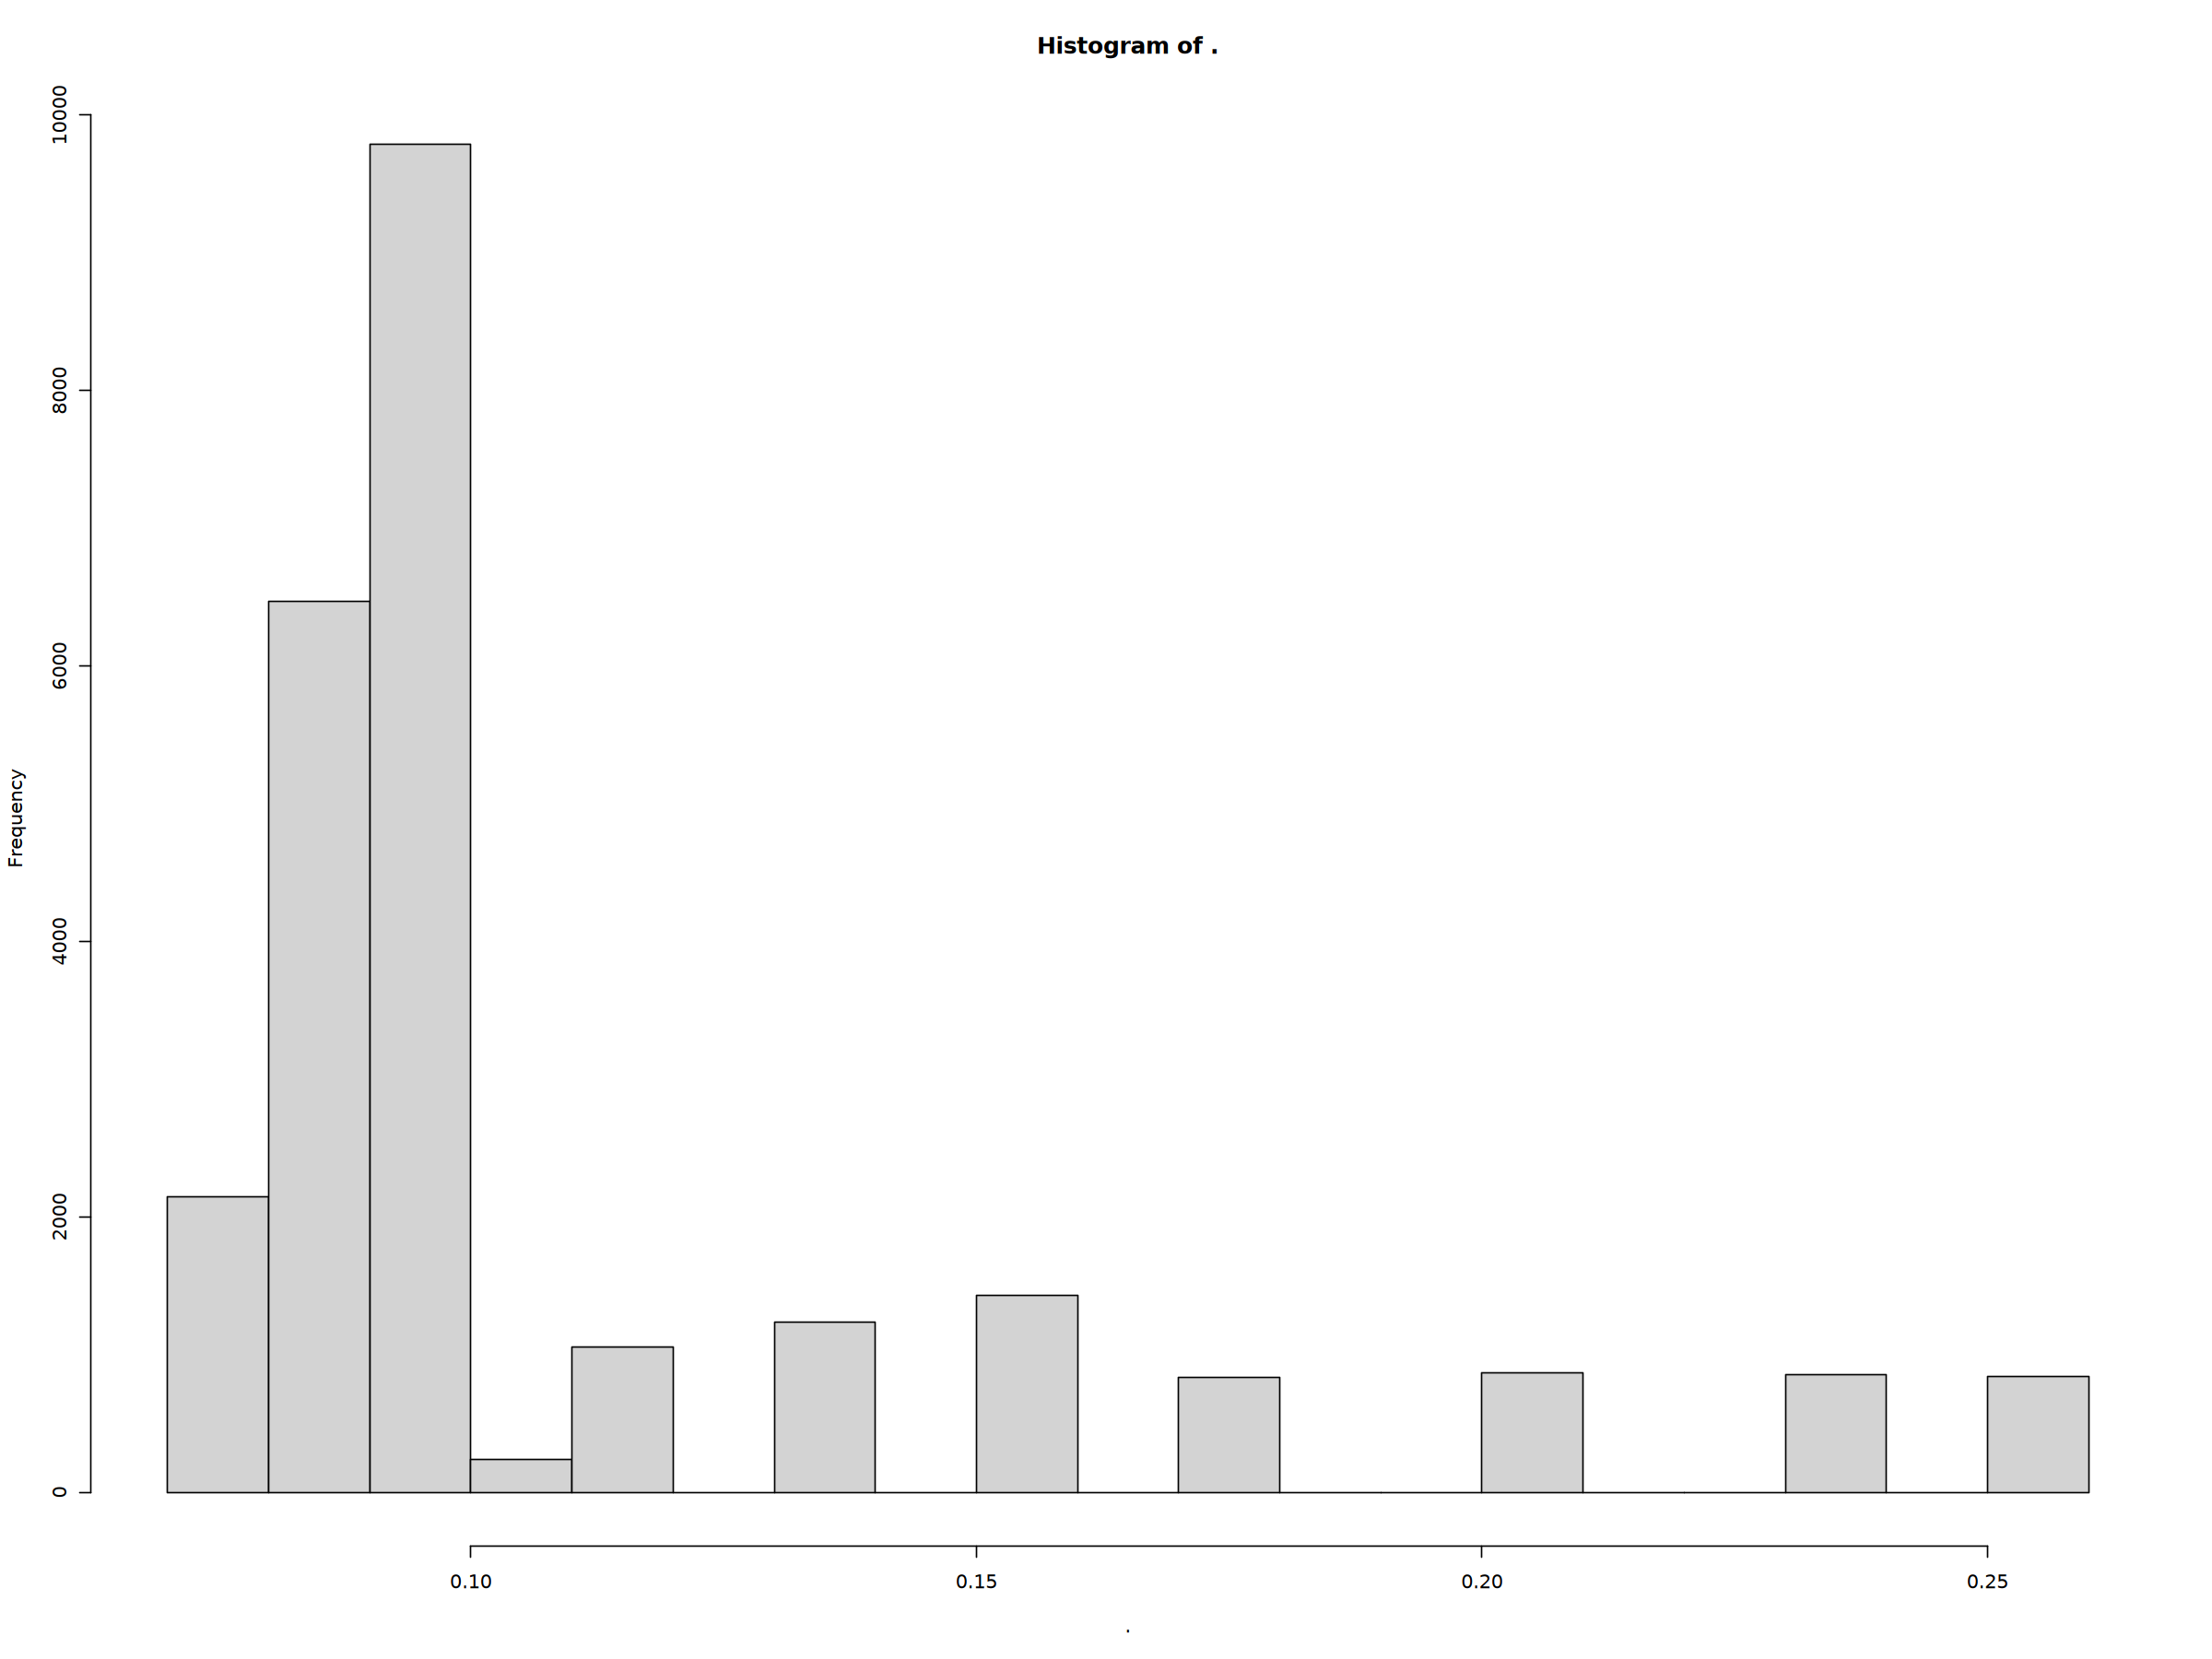

In [59]:
cd4na_diff$P_value %>% hist()
cd4na_diff$FDR %>% hist()

In [ ]:
cd4na_diff_table <- cd4na_diff %>%
  as_tibble() %>%
  filter(!is.na(P_value)) %>%
  rstatix::adjust_pvalue(p.col = "P_value", output.col = "p_adj", method = "BY")

In [ ]:
# annotate the differential tile
cd4na_diff <- cd4na_diff %>% annotateTiles(
  TxDb = TxDb,
  Org = Org
)

In [60]:
cd4na_diff %>% saveRDS(file.path(
  output_path,
  paste0(proj_name, "_MOCHA_total_cd4na_ravshealthy_DAPs.rds")
))

In [22]:
# load differential DAPS between pre-RA and healthy in cd4 naive
cd4na_diff <- readRDS("/home/workspace/data/preRA_teaseq/output_results/atac/preRA_tea_seq_cd4tna_MOCHA_total_cd4na_ravshealthy_DAPs.rds")

In [13]:
cd4na_diff %>%
  as_tibble() %>%
  write_csv(file.path(output_path, paste0(proj_name, "cd4na_atac_daps.csv")))

In [23]:
cd4na_diff %>%
  as_tibble() %>%
  filter(FDR < 0.1 & P_value < 0.05) %>%
  group_by(tileType) %>%
  tally()

tileType,n
<chr>,<int>
Distal,829
Promoter,2200


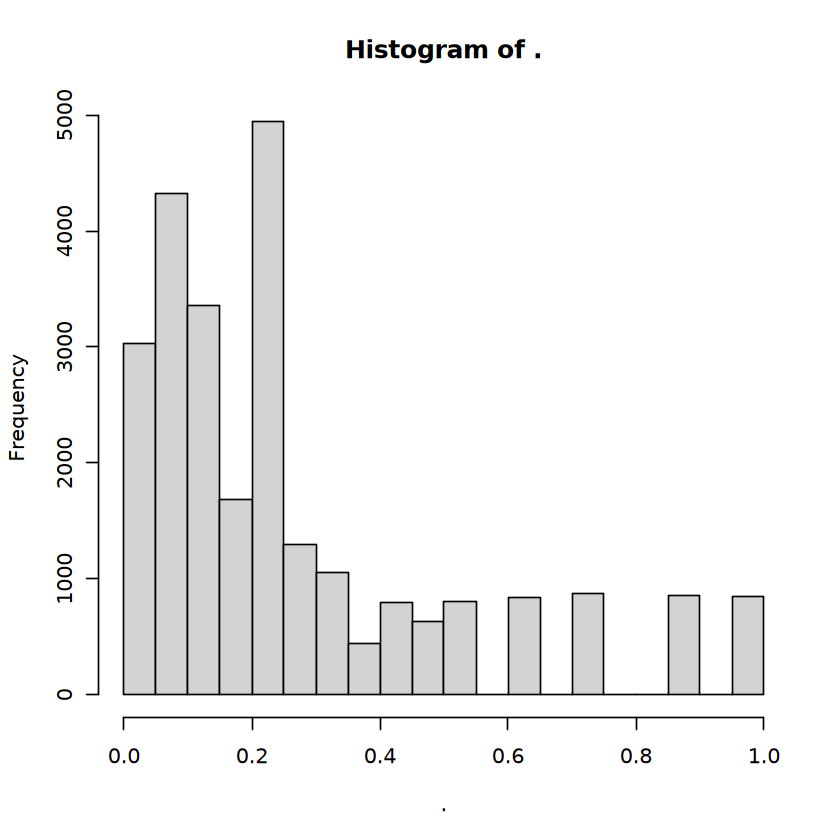

In [24]:
cd4na_diff %>%
  as_tibble() %>%
  pull(P_value) %>%
  hist()

In [25]:
cd4na_diff_sig <- cd4na_diff %>%
  as_tibble() %>%
  filter(FDR < 0.1 & P_value < 0.05)
cd4na_diff_sig %>%
  group_by(tileType) %>%
  tally()

tileType,n
<chr>,<int>
Distal,829
Promoter,2200


In [27]:
cd4na_diff %>%
  as_tibble() %>%
  filter(FDR < 0.1 & P_value < 0.05 & str_detect(Gene, "IL21|IL6R"))

seqnames,start,end,width,strand,Tile,CellPopulation,Foreground,Background,P_value,Test_Statistic,FDR,Log2FC_C,MeanDiff,Avg_Intensity_Case,Pct0_Case,Avg_Intensity_Control,Pct0_Control,tileType,Gene
<fct>,<int>,<int>,<int>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
chr1,154457000,154457499,500,*,chr1:154457000-154457499,cd4_naive,pre-RA,Healthy,0.022773310,5.185714,0.07081977,-0.3294576,5.330089,6.585962,0,6.915419,0.8,Promoter,IL6R
chr4,122617500,122617999,500,*,chr4:122617500-122617999,cd4_naive,pre-RA,Healthy,0.004101401,8.238367,0.07081977,NA,7.583888,7.713772,0,NA,1.0,Promoter,IL21


In [31]:
# take the significant peaks
cd4na_diff_sig <- cd4na_diff[(!is.na(elementMetadata(cd4na_diff)[, "FDR"])) &
  (!is.na(elementMetadata(cd4na_diff)[, "Log2FC_C"])) &
  (elementMetadata(cd4na_diff)[, "FDR"] < 0.1)]

In [32]:
cd4na_diff_sig

GRanges object with 17442 ranges and 15 metadata columns:
          seqnames              ranges strand |                   Tile
             <Rle>           <IRanges>  <Rle> |            <character>
      [1]     chr1 100040000-100040499      * | chr1:100040000-10004..
      [2]     chr1 100060500-100060999      * | chr1:100060500-10006..
      [3]     chr1 100247500-100247999      * | chr1:100247500-10024..
      [4]     chr1 100297500-100297999      * | chr1:100297500-10029..
      [5]     chr1   10032500-10032999      * | chr1:10032500-10032999
      ...      ...                 ...    ... .                    ...
  [17438]     chrX     9291500-9291999      * |   chrX:9291500-9291999
  [17439]     chrX     9346000-9346499      * |   chrX:9346000-9346499
  [17440]     chrX     9421000-9421499      * |   chrX:9421000-9421499
  [17441]     chrX     9497500-9497999      * |   chrX:9497500-9497999
  [17442]     chrX       978500-978999      * |     chrX:978500-978999
          CellPopul

# plot Fig 6F IL21 accessibility

In [8]:
# # load the sample tile matrix
SampleTileMatricesAnnotated <- readRDS(file.path(
  output_path,
  paste0(proj_name, "_MOCHA_total_cd4na_SampleTileMatrices.rds")
))

In [9]:
SampleTileMatricesAnnotated

class: RangedSummarizedExperiment 
dim: 517979 12 
metadata(7): summarizedData Genome ... History Motifs
assays(1): cd4_naive
rownames(517979): chr1:1000000-1000499 chr1:100006000-100006499 ...
  chrX:9997500-9997999 chrY:26409000-26409499
rowData names(3): cd4_naive tileType Gene
colnames(12): EXP-00243-P1_PB00060-02 EXP-00243-P1_PB00065-05 ...
  EXP-00243-P1_PB00561-03 EXP-00243-P1_PB00569-04
colData names(11): Sample pool_id ... clean_l2_cell_types
  cd4t_annotation

In [30]:
# make status column
colData(SampleTileMatricesAnnotated)$status <- factor(if_else(colData(SampleTileMatricesAnnotated)$cohort == "pre-RA",
  "ARI", "CON2"
), levels = c("CON2", "ARI"))
SampleTileMatricesAnnotated$status %>% unique()

[1] ARI  CON2
Levels: CON2 ARI

In [31]:
# import the gene database
txList <- suppressWarnings(GenomicFeatures::transcriptsBy(TxDb, by = ("gene")))
names(txList) <- suppressWarnings(AnnotationDbi::mapIds(Org, names(txList), "SYMBOL", "ENTREZID"))

'select()' returned 1:1 mapping between keys and columns



In [32]:
# get the gene names and gene ranges
gene_name <- "IL21"
# peak_ranges_str <- cd4na_prom_gex_sig %>% filter(gene==gene_name)
gene_ranges <- txList[[gene_name]] %>%
  as_tibble() %>%
  mutate(gene_range = paste0(seqnames, ":", start - 2000, "-", end + 2000))
gene_ranges
gene_ranges[1, ]$gene_range

seqnames,start,end,width,strand,tx_id,tx_name,gene_range
<fct>,<int>,<int>,<int>,<fct>,<int>,<chr>,<chr>
chr4,122610108,122621066,10959,-,20591,NM_021803,chr4:122608108-122623066
chr4,122612628,122621057,8430,-,20592,NM_001207006,chr4:122610628-122623057


[1] "chr4:122608108-122623066"

In [33]:
# update Directory to connect to coverage file
SampleTileMatricesAnnotated@metadata$Directory <- "/home/workspace/data/preRA_teaseq/EXP-00243/cd4tna_cells/MOCHA"

In [34]:
SampleTileMatricesAnnotated@metadata$Motifs

GRangesList object of length 870:
$TFAP2B
GRanges object with 57262 ranges and 1 metadata column:
          seqnames              ranges strand |     score
             <Rle>           <IRanges>  <Rle> | <numeric>
      [1]     chr1 100132718-100132729      + |   8.07402
      [2]     chr1     1003016-1003027      + |   9.39208
      [3]     chr1     1003016-1003027      - |   9.23577
      [4]     chr1 100348751-100348762      + |   9.04218
      [5]     chr1     1003978-1003989      + |   8.88001
      ...      ...                 ...    ... .       ...
  [57258]     chrX       980938-980949      + |   8.75477
  [57259]     chrX       980938-980949      - |   9.21500
  [57260]     chrX     9997269-9997280      + |   8.65688
  [57261]     chrY   26409440-26409451      + |   8.03696
  [57262]     chrY   26409440-26409451      - |   8.81406
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

...
<869 more elements>

In [35]:
####################################################
# 5. (Optional) Plot a specific region's coverage.
#    Here we plot coverage at a specific region and
#    gene by infection stage.
####################################################
countSE <- MOCHA::extractRegion(
  SampleTileObj = SampleTileMatricesAnnotated,
  cellPopulations = "cd4_naive",
  region = gene_ranges[1, ]$gene_range,
  groupColumn = "status",
  numCores = 3,
  sampleSpecific = FALSE
)

In [36]:
# add delta
countSE <- addAccessibilityShift(countSE,
  foreground = "cd4_naive.ARI",
  background = "cd4_naive.CON2"
)

In [37]:
pdf(
  file.path(fig_path, paste0(
    proj_name, "_peak_regions_preRAvsHealthy_",
    gene_name, "_status.pdf"
  )),
  width = 4, height = 4
)
# Note that to show specific genes with the option
# 'whichGene' you must have the package RMariaDB
# installed
p1 <- MOCHA::plotRegion(
  countSE = countSE,
  whichGene = gene_name, counts_group_colors = c("#F59F00", "#5AAA46", "#840032")
)
p1
dev.off()

'select()' returned 1:1 mapping between keys and columns



pdf 
  2

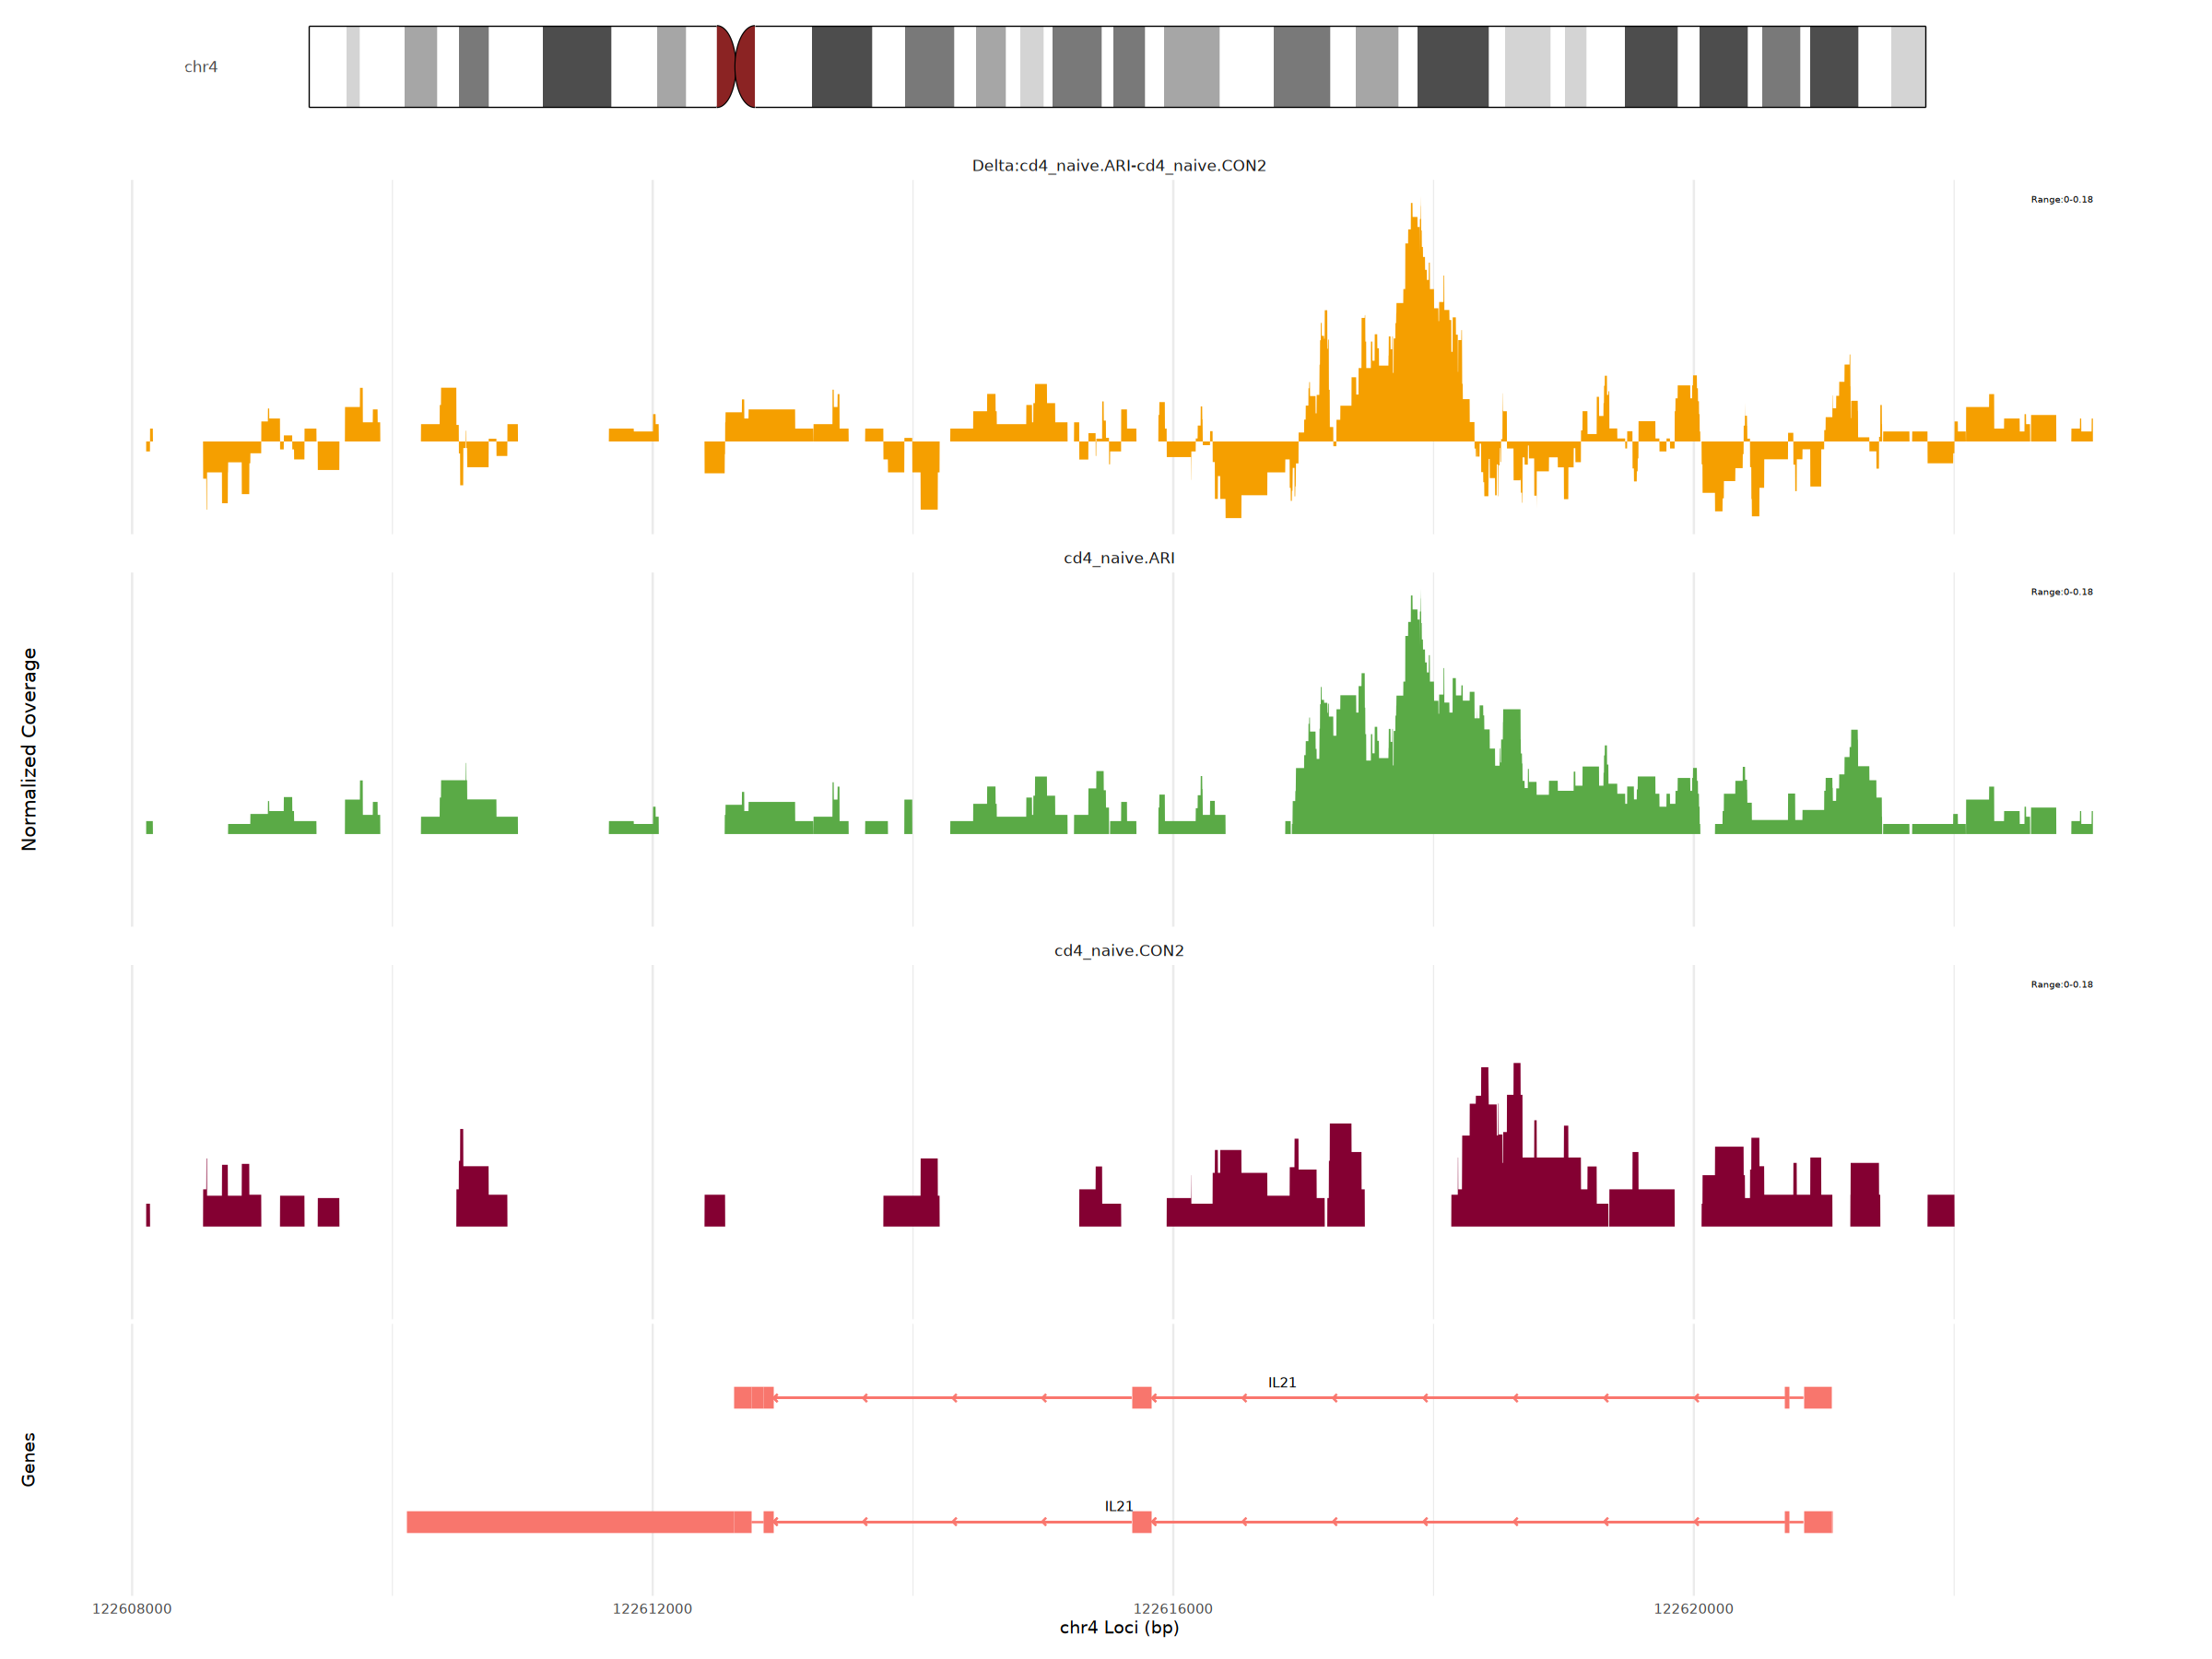

In [38]:
p1

### only plot STAT3 and BCL6 motifs

In [39]:
# metadata(countSE)$Motifs%>%names()
motif_plot <- c("BCL6", "STAT3")
metadata(countSE)$Motifs_Trim <- metadata(countSE)$Motifs[names(metadata(countSE)$Motifs) %in% motif_plot]

In [40]:
IL21_peaks <- GRanges(seqnames = "chr4", ranges = IRanges(start = 122617000, end = 122617999))
metadata(countSE)$Motifs_Trim$BCL6 %>% subsetByOverlaps(IL21_peaks, type = "any")

GRanges object with 2 ranges and 1 metadata column:
      seqnames              ranges strand |     score
         <Rle>           <IRanges>  <Rle> | <numeric>
  [1]     chr4 122617270-122617285      + |   8.44040
  [2]     chr4 122617344-122617359      + |   7.80133
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [41]:
print("STAT3")
metadata(countSE)$Motifs_Trim$STAT3 %>% subsetByOverlaps(IL21_peaks, type = "any")

[1] "STAT3"


GRanges object with 2 ranges and 1 metadata column:
      seqnames              ranges strand |     score
         <Rle>           <IRanges>  <Rle> | <numeric>
  [1]     chr4 122617341-122617355      + |   8.03210
  [2]     chr4 122617556-122617570      + |   8.28808
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [42]:
pdf(
  file.path(fig_path, paste0(
    proj_name, "_peak_regions_preRAvsHealthy_",
    gene_name, "_status_motif.pdf"
  )),
  width = 10, height = 10
)
p1 <- MOCHA::plotRegion(
  countSE = countSE, motifSetName = "Motifs_Trim",
  motif_lab_size = 3, motif_lab_alpha = 0.5, motif_line_alpha = 0.5,
  whichGene = gene_name, counts_group_colors = c("#F59F00", "#5AAA46", "#840032")
)
p1
dev.off()

'select()' returned 1:1 mapping between keys and columns

Warning message:
"Removed 2680 rows containing non-finite outside the scale range
(`stat_align()`)."


pdf 
  2

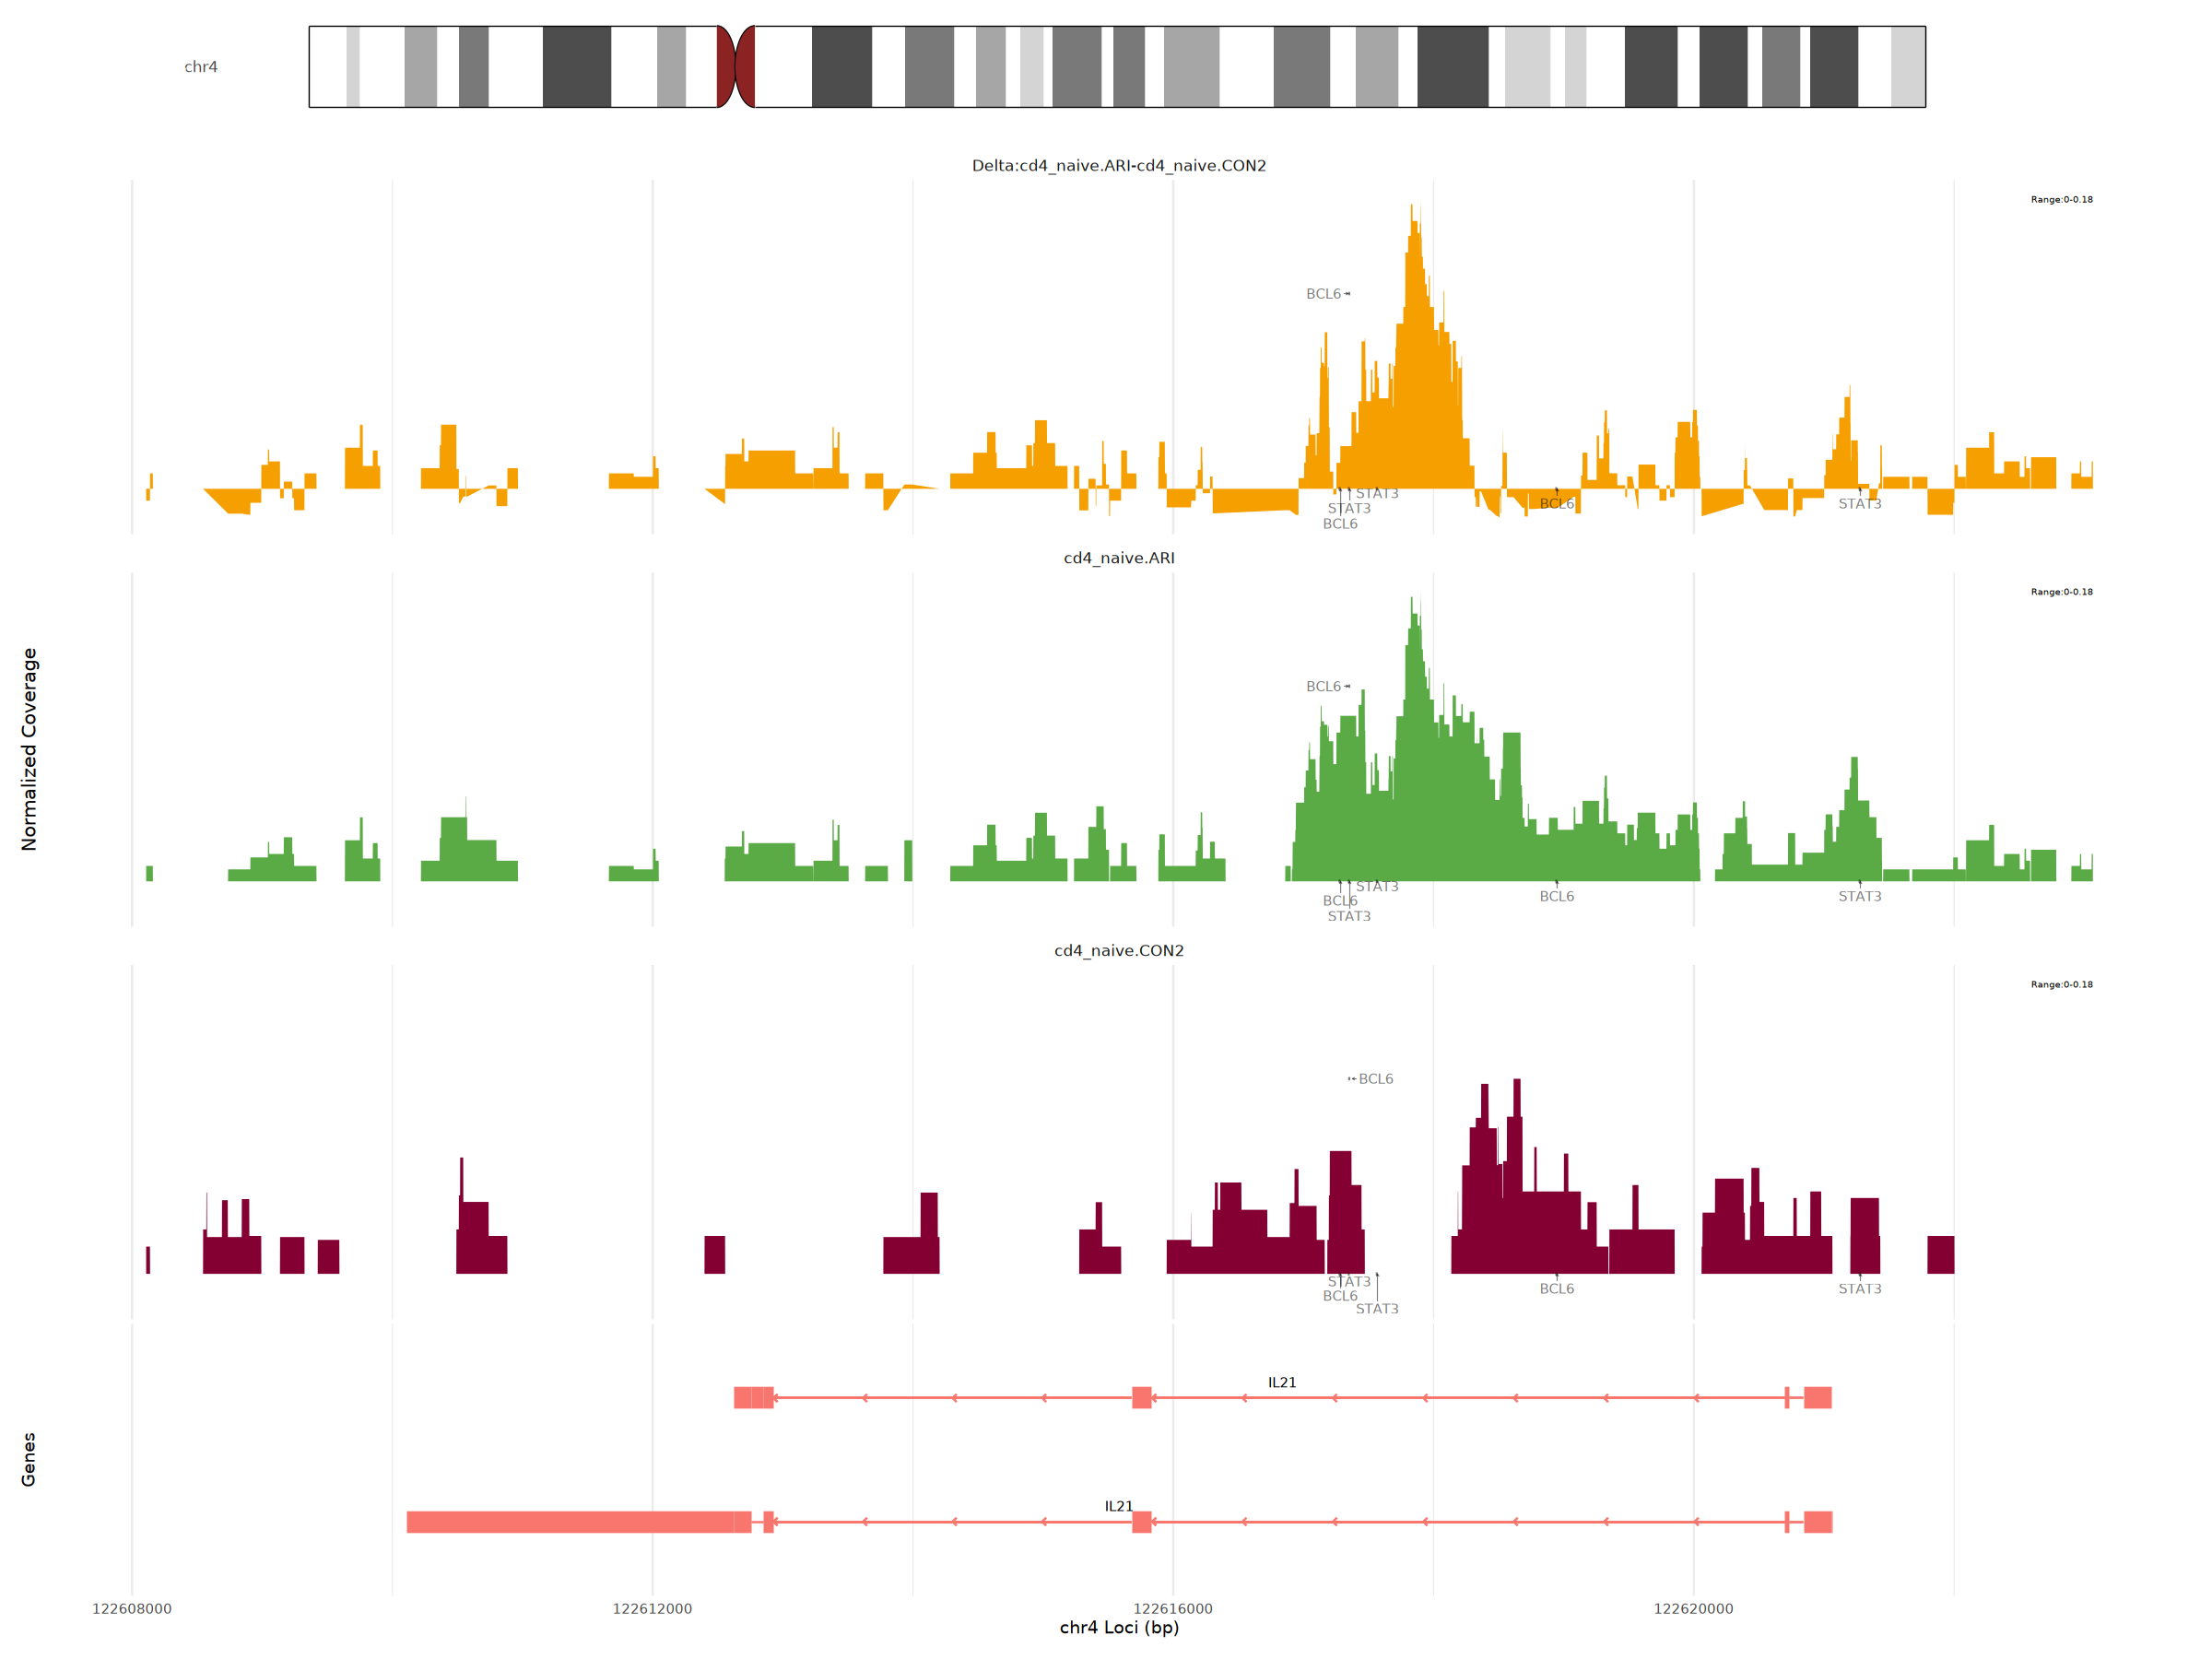

In [43]:
p1

### plot other peaks

In [44]:
# define a function to plot gene tracks
PlotPromoterRegion <- function(SampleTileObj, gene_name, cellPopulations, groupColumn, numCores = 15,
                               sampleSpecific = FALSE, ...) {
  gene_ranges <- txList[[gene_name]] %>%
    as_tibble() %>%
    mutate(gene_range = paste0(seqnames, ":", start - 2000, "-", end + 2000))
  countSE <- MOCHA::extractRegion(
    SampleTileObj = SampleTileObj,
    cellPopulations = cellPopulations,
    region = gene_ranges$gene_range[1],
    groupColumn = groupColumn,
    numCores = numCores,
    sampleSpecific = sampleSpecific
  )
  # add delta
  # add delta
  countSE <- addAccessibilityShift(countSE,
    foreground = paste0(cellPopulations, ".ARI"),
    background = paste0(cellPopulations, ".CON2")
  )
  pdf(file.path(fig_path, paste0(
    proj_name, "atac_annotate_", cellPopulations, "_",
    gene_name, "_gene_regions.pdf"
  )), width = 5, height = 5)
  p1 <- MOCHA::plotRegion(countSE = countSE, whichGene = gene_name, ...)
  print(p1)
  dev.off()
  return(p1)
}

In [45]:
SampleTileMatricesAnnotated

class: RangedSummarizedExperiment 
dim: 517979 12 
metadata(7): summarizedData Genome ... History Motifs
assays(1): cd4_naive
rownames(517979): chr1:1000000-1000499 chr1:100006000-100006499 ...
  chrX:9997500-9997999 chrY:26409000-26409499
rowData names(3): cd4_naive tileType Gene
colnames(12): EXP-00243-P1_PB00060-02 EXP-00243-P1_PB00065-05 ...
  EXP-00243-P1_PB00561-03 EXP-00243-P1_PB00569-04
colData names(12): Sample pool_id ... cd4t_annotation status

In [46]:
gene_name <- "IL6R"
txList[[gene_name]] %>%
  as_tibble() %>%
  mutate(gene_range = paste0(seqnames, ":", start - 2000, "-", end + 2000))

seqnames,start,end,width,strand,tx_id,tx_name,gene_range
<fct>,<int>,<int>,<int>,<fct>,<int>,<chr>,<chr>
chr1,154405343,154438085,32743,+,2407,NM_001206866,chr1:154403343-154440085
chr1,154405343,154469450,64108,+,2408,NM_000565,chr1:154403343-154471450
chr1,154405343,154469450,64108,+,2409,NM_001382769,chr1:154403343-154471450
chr1,154405343,154469450,64108,+,2410,NM_001382770,chr1:154403343-154471450
chr1,154405343,154469450,64108,+,2411,NM_001382771,chr1:154403343-154471450
chr1,154405343,154469450,64108,+,2412,NM_001382772,chr1:154403343-154471450
chr1,154405343,154469450,64108,+,2413,NM_001382773,chr1:154403343-154471450
chr1,154405343,154469450,64108,+,2414,NM_001382774,chr1:154403343-154471450
chr1,154405343,154469450,64108,+,2415,NM_181359,chr1:154403343-154471450


'select()' returned 1:1 mapping between keys and columns



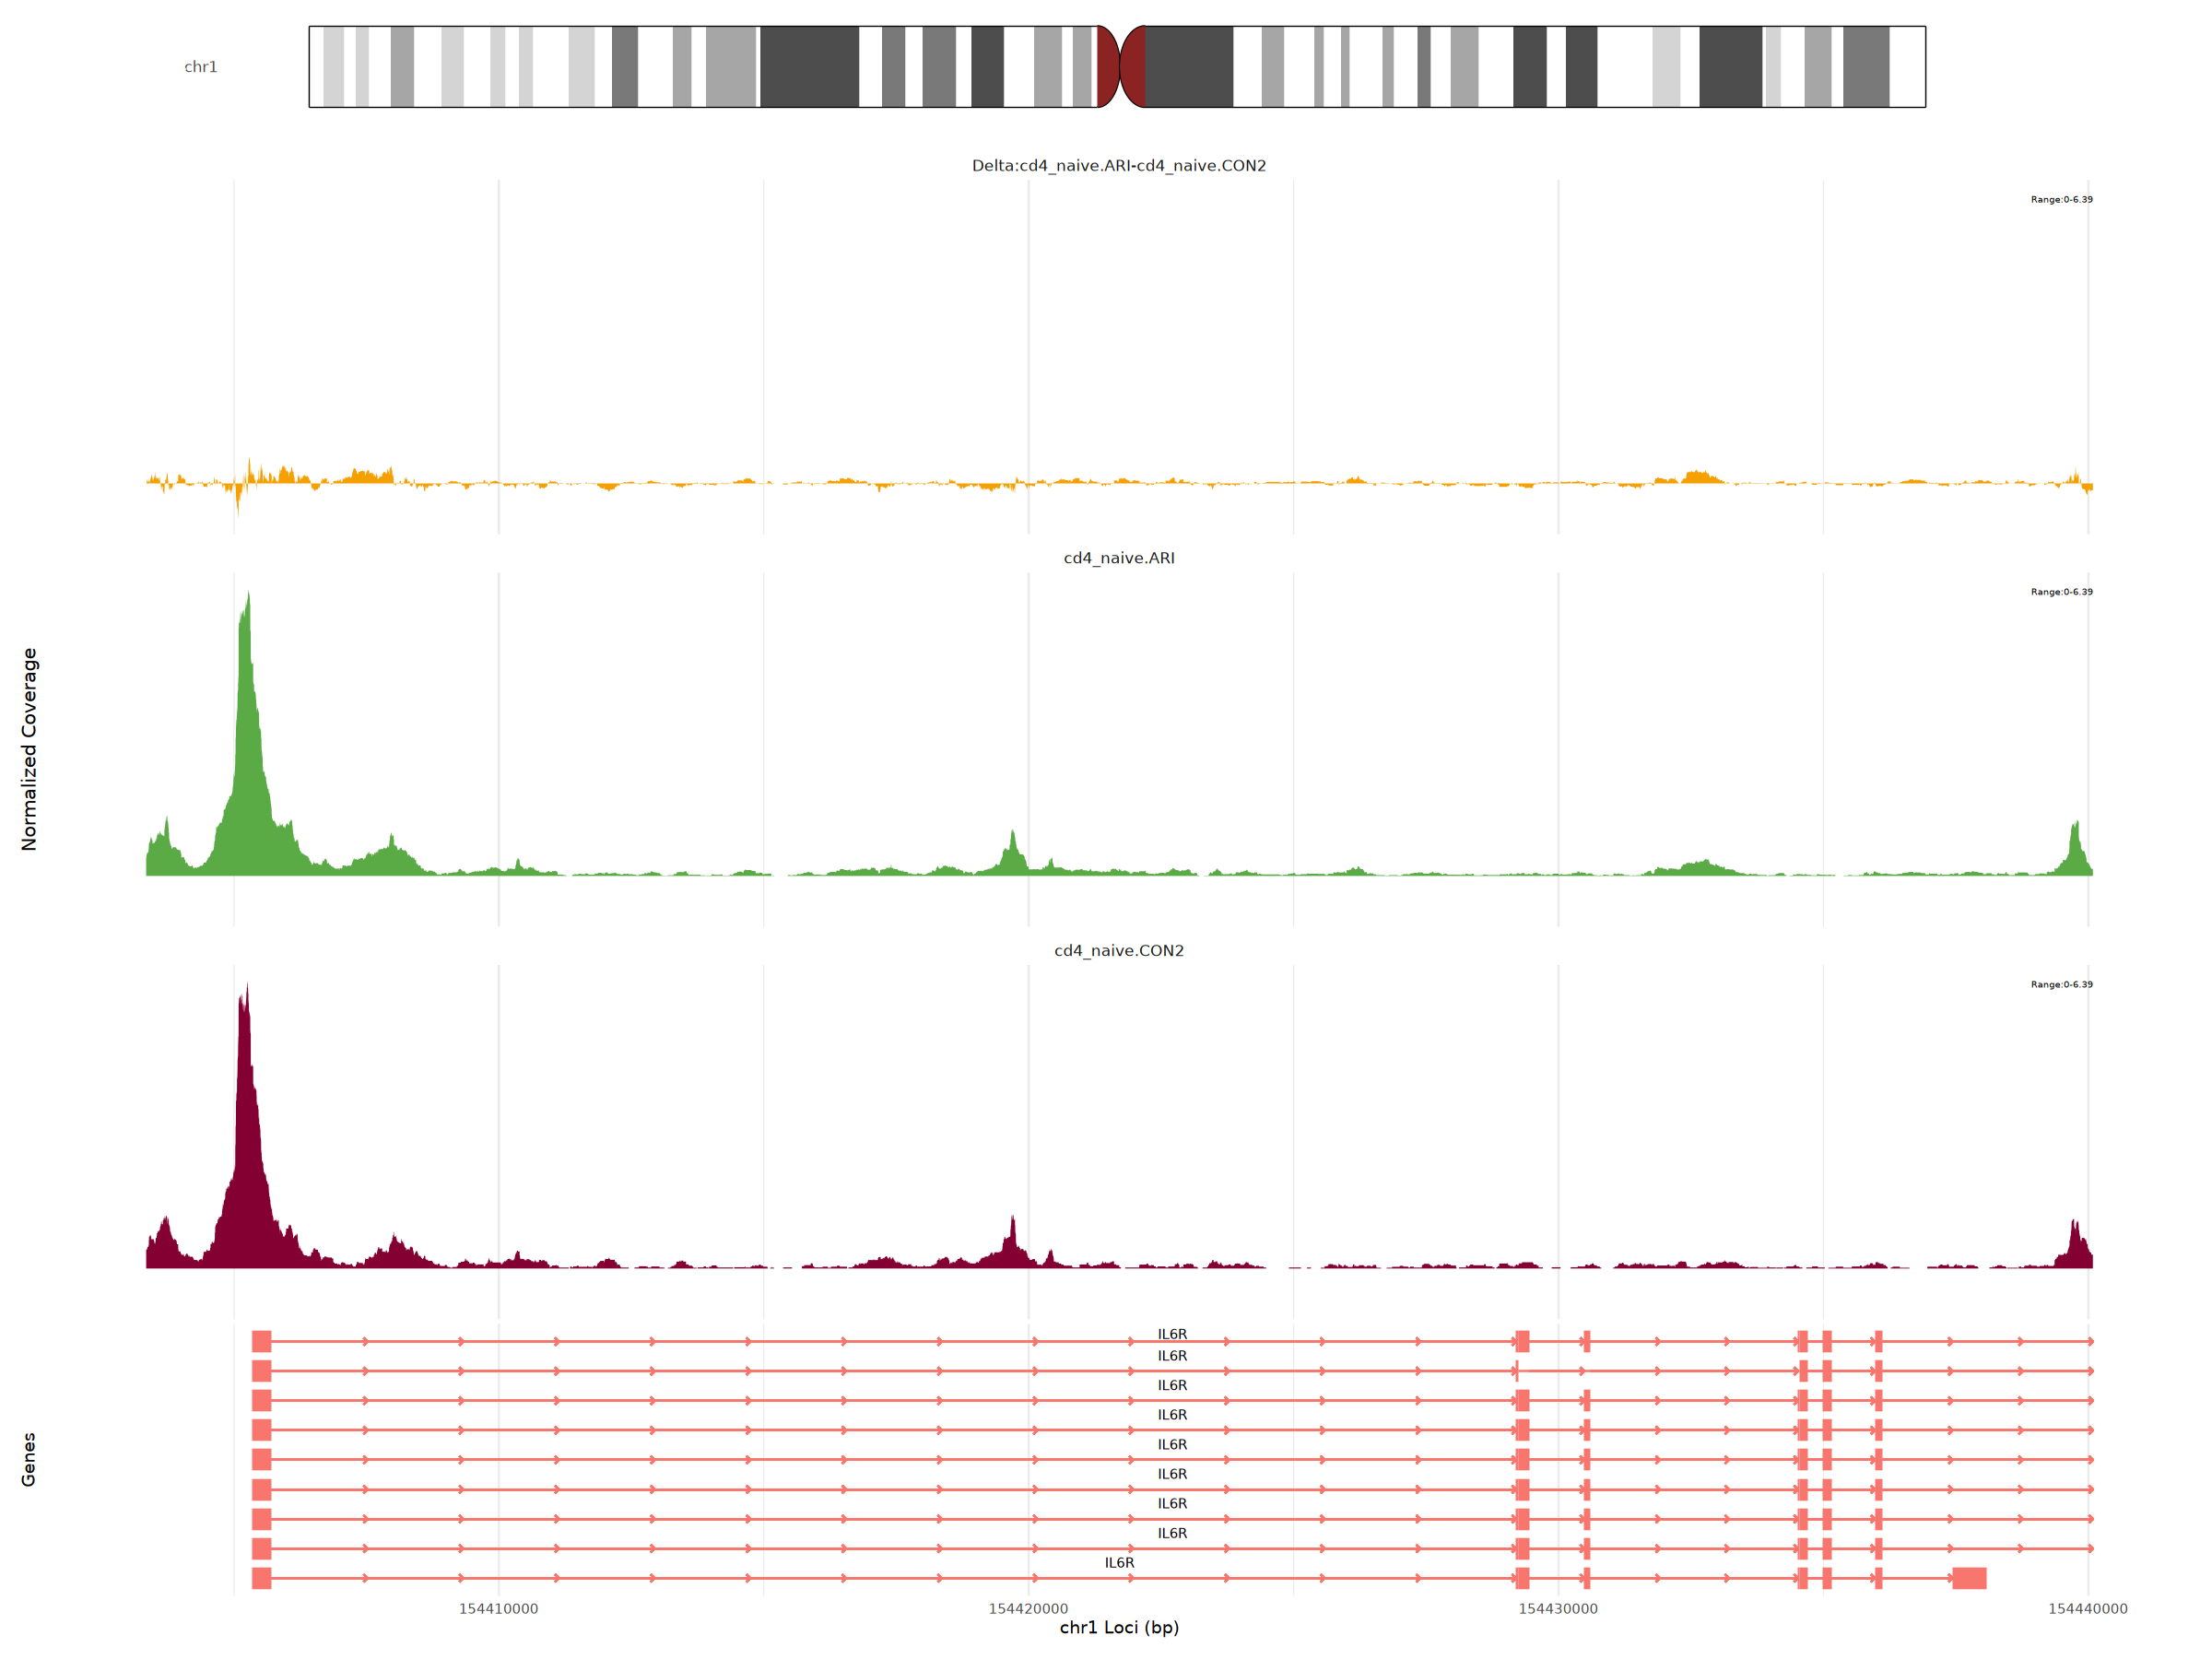

In [47]:
PlotPromoterRegion(
  SampleTileObj = SampleTileMatricesAnnotated, gene_name = "IL6R",
  cellPopulations = "cd4_naive", groupColumn = "status",
  counts_group_colors = c("#F59F00", "#5AAA46", "#840032")
)

In [48]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_atac/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

Random number generation:
 RNG:     L'Ecuyer-CMRG 
 Normal:  Inversion 
 Sample:  Rejection 
 
locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
 [1] parallel  stats4    grid      stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] org.Hs.eg.db_3.20.0                   
 [2] TxDb.Hsapiens.UCSC.hg38.refGene_3.19.0
 [3] GenomicFeatures_1.58.0                
 [4] AnnotationDbi_1.68.0                  
 [5] plyranges_